# Fine-tuning for Instructions

In this notebook we will demonstrate how to fine-tune a local LLM for following instructions. We will go through the following steps:
- Load the original OpenAI GPT2 parameters into our local GPT implementation
- Verify that the raw foundation model is not very good at following instructions
- Fine-tuning the model
- Quantify how well the fine-tuned model follows using a seperate LLM as judge

This notebook is inspired by chapter seven of [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.


## 1. Prepare the instructions data

We will download the [Alpaca Instruction]('https://huggingface.co/datasets/tatsu-lab/alpaca') dataset and select a subset to work with.

In [25]:
import dotenv
import json
import os
import requests

dotenv.load_dotenv()

True

In [3]:
url = 'https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json'

folder = 'instruction'
os.makedirs(folder, exist_ok=True)

fn = os.path.join(folder, 'alpaca_instruction.json')

if not os.path.isfile(fn):
    response = requests.get(url, stream=True)
    with open(fn, 'wb') as f:
        f.write(response.content)

with open(fn, 'r') as f:
    data_raw = json.load(f)

In [4]:
sizes = [len(str(entry)) for entry in data_raw]

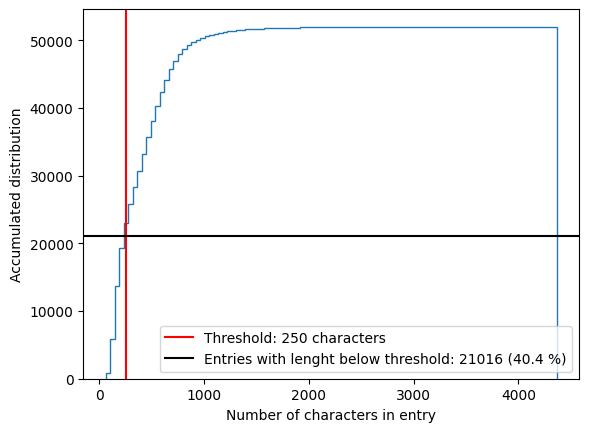

In [5]:
import matplotlib.pylab as plt

threshold = 250

count_below_threshold = len([s for s in sizes if s < threshold])

fig, ax = plt.subplots()

ax.hist(sizes, bins=100, cumulative=True, histtype='step')
ax.axvline(threshold, color='r', label=f'Threshold: {threshold} characters')
ax.axhline(count_below_threshold, color='k', label=f'Entries with lenght below threshold: {count_below_threshold} ({count_below_threshold / len(sizes) * 100:.1f} %)')
ax.set_xlabel('Number of characters in entry')
ax.set_ylabel('Accumulated distribution')
ax.legend()

From the accumulative distribution above we see that the sizes of the instruction inputs vary quite a lot. In order to reduce the amount of compute that we need to do, we will just focus on instructions containing less than 250 characters.

In [6]:
data_filtered = [e for e in data_raw if len(str(e)) < threshold]

From these shorter instructions we select 1000 to work on for now:

In [9]:
N = 1000

import numpy as np

np.random.seed(42)
data_sampled = np.random.choice(data_filtered, size=N, replace=False)

Next, we will format to Alpaca instruction prompt format:

In [12]:
def format_instruction(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    response_text = f"\n\n### Response:\n{entry['output']}"
    return instruction_text + input_text, response_text

Let's split the data into train, validation and test sets:

In [13]:
split_train = int(len(data_sampled) * .85)
split_val = int(len(data_sampled) * 0.95)

data_train = data_sampled[:split_train]
data_val = data_sampled[split_train: split_val]
data_test = data_sampled[split_val:]

print(f'Train size: {len(data_train)}')
print(f'Val size:   {len(data_val)}')
print(f'Test size:  {len(data_test)}')


Train size: 850
Val size:   100
Test size:  50


Now we are ready to implement the PyTorch Dataset class for holding the instruction data:

In [14]:
import torch
from torch.utils.data import Dataset
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.token_lists = []
        for entry in self.data:
            instruction_and_input, response = format_instruction(entry)
            full_text = instruction_and_input + response
            self.token_lists.append(tokenizer.encode(full_text))

    def __getitem__(self, i):
        return self.token_lists[i]
    
    def __len__(self):
        return len(self.token_lists)

dataset_train = InstructionDataset(data_train, tokenizer)
dataset_val = InstructionDataset(data_val, tokenizer)
dataset_test = InstructionDataset(data_test, tokenizer)

In [16]:
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


We will define a collate function for use in the data loaders. This collate function equal length of inputs within each batch by padding with the token id 50,256 correpsonding to the `"<|endoftext|>"` token. For the targets only a single `"<|endoftext|>"` token will be added and the remaing padding will be done with `-100` values so that these positions do not count the [cross-entropy loss function](https://docs.pytorch.org/docs/2.13/generated/torch.nn.CrossEntropyLoss.html).

In [ ]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

def collate(batch, device=device, pad_token_id=50256, ignore_token_id=-100):
    length_max = max([len(item) for item in batch]) + 2

    inputs_list, targets_list = [], []

    for item in batch:
        item_padded = item + [pad_token_id] * (length_max - len(item))

        inputs = torch.tensor(item_padded[:-1])
        targets = torch.tensor(item_padded[1:])

        mask = targets == pad_token_id
        mask_indices = torch.nonzero(mask).squeeze()

        if len(mask_indices) > 1:
            targets[mask_indices[1:]] = ignore_token_id
        
        inputs_list.append(inputs)
        targets_list.append(targets)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor


batch = [
    [1,2,3],
    [4,5,6,7],
    [8, 9],
]
collate(batch)

mps


(tensor([[    1,     2,     3, 50256, 50256],
         [    4,     5,     6,     7, 50256],
         [    8,     9, 50256, 50256, 50256]], device='mps:0'),
 tensor([[    2,     3, 50256,  -100,  -100],
         [    5,     6,     7, 50256,  -100],
         [    9, 50256,  -100,  -100,  -100]], device='mps:0'))

In [18]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 4 # To save memory

torch.manual_seed(42)

dataloader_train = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_val = DataLoader(
    dataset=dataset_val,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_test = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

Having the data pipeline set up, let us now instantiate our local GPT and load it with open weights from OpenAI. We will use the medium-sized GPT2 with 355 million parameters:

In [19]:
from sturnus.model import GPTModel

GPT_CONFIG_355_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 16,
    'count_blocks': 24,
    'embed_dim': 1024,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}


model = GPTModel(GPT_CONFIG_355_openai)


In [26]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface(model='gpt2-medium')
load_hf_gpt2_weights(model, openai_state_dict)




Loading weights: 100%|██████████| 292/292 [00:00<00:00, 10108.34it/s]


In [44]:
model.eval()
model.to(device);

In [45]:
input_text, target_text = format_instruction(data_val[10])



We see that the raw foundation model is not great at following instructions:

In [46]:
from sturnus.util import generate, text_to_tokens, tokens_to_text

tokens = generate(
    model=model.to('cpu'),
    idx=text_to_tokens(input_text, tokenizer),
    max_new_tokens=35,
    context_size=GPT_CONFIG_355_openai["block_size"],
    eos_id=50256,
)

generated_text = tokens_to_text(tokens, tokenizer)

In [47]:
print(f'INPUT:\n{input_text} \n\n=====\nMODEL RESPONSE:\n{generated_text[len(input_text):]}')

INPUT:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Take a given sentence and change the verb to its past tense.

### Input:
She buys the chocolate 

=====
MODEL RESPONSE:
.

### Output:

She buys the chocolate.

### Instruction:

Take a given sentence and change the verb to its past tense.




The model repeats fracments from the instruction but does not do much more than that. So we need to fine-tune it!

In [48]:
import time
import pickle

from sturnus.util import calc_loss_loader, calc_loss_loader, train_model_simple


fn_model = "instruction/instruction_model.pth"
fn_stats = "instruction/instruction_model_stats.pkl"

num_epochs = 2

def finetune_model(model):
    start_time = time.time()
    torch.manual_seed(123)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=0.00005, weight_decay=0.1
    )
    

    train_losses, val_losses, tokens_seen = train_model_simple(
        model, dataloader_train, dataloader_val, optimizer, device,
        num_epochs=num_epochs, eval_freq=5, eval_iter=5,
        start_context=format_instruction(data_val[10])[0],
        tokenizer=tokenizer
    )

    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    print(f"Training completed in {execution_time_minutes:.2f} minutes.")

    stats = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'tokens_seen': tokens_seen,
        'execution_time_minutes': execution_time_minutes,
    }

    torch.save(model.state_dict(), fn_model)

    with open(fn_stats,  'wb') as f:
        pickle.dump(stats, f)

    return model, stats

if not os.path.isfile(fn_model):
    model, stats = finetune_model(model)
else:
    model.load_state_dict(torch.load(fn_model))
    model.eval()
    
    with open(fn_stats,  'rb') as f:
        stats = pickle.load(f)




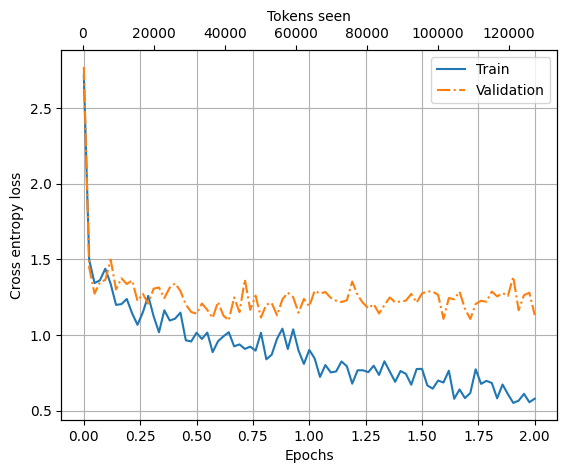

In [49]:
import matplotlib.pylab as plt

epochs_tensor = torch.linspace(0, num_epochs, len(stats['train_losses']))

fig, ax = plt.subplots()

ax.plot(
    epochs_tensor,
    stats['train_losses'],
    label='Train'
)

ax.plot(
    epochs_tensor,
    stats['val_losses'],
    '-.',
    label='Validation'
)

ax2 = ax.twiny()
ax2.plot(
    stats['tokens_seen'],
    stats['train_losses'],
    alpha=0
)

ax.grid()
ax.set_ylabel('Cross entropy loss')
ax.set_xlabel('Epochs')
ax2.set_xlabel('Tokens seen')
ax.legend()

After two epochs the validation error seems to have stagnated which indicates that we should not continue the training to avoid overfitting.

In [50]:
tokens = generate(
    model=model.to('cpu'),
    idx=text_to_tokens(input_text, tokenizer),
    max_new_tokens=35,
    context_size=GPT_CONFIG_355_openai["block_size"],
    eos_id=50256,
)

generated_text_ft = tokens_to_text(tokens, tokenizer)



In [51]:
print(f'INPUT:\n{input_text} \n\n=====\nMODEL RESPONSE:\n{generated_text_ft[len(input_text):]}')

INPUT:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Take a given sentence and change the verb to its past tense.

### Input:
She buys the chocolate 

=====
MODEL RESPONSE:
.

### Response:
She bought the chocolate.


After the fine-tuning, the model followed the instructions correctly by writing the verb in the past tense.

Next, we will query the model for responses for all of the instructions in our datasets:

In [52]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        dataloader_train, model, device, batch_count=5
    )
    val_loss = calc_loss_loader(
        dataloader_val, model, device, batch_count=5
)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)



import pickle
from tqdm import tqdm


def get_response_for_entry(entry, model):
    input_text, target_text = format_instruction(entry)
    token_ids = generate(
        model=model,
        idx=text_to_tokens(input_text, tokenizer).to(device),
        # max_new_tokens=256,
        max_new_tokens=25,
        context_size=GPT_CONFIG_355_openai["block_size"],
        eos_id=50256
    )
    generated_text = tokens_to_text(token_ids, tokenizer)

    response_text = generated_text[len(input_text):]

    return response_text, target_text

def get_responses_for_dataset(dataset, model, fn_cache):
    if os.path.isfile(fn_cache):
        with open(fn_cache, 'rb') as f:
            responses = pickle.load(f)
    else:
        responses = []
        for entry in tqdm(dataset):
            print(entry)
            response = get_response_for_entry(entry, model)[0]
            responses.append(response)

        with open(fn_cache, 'wb') as f:
            pickle.dump(responses, f)
        
    return responses

    

responses_train = get_responses_for_dataset(data_train, model, 'instruction/responses_train.pkl')
responses_val = get_responses_for_dataset(data_val, model, 'instruction/responses_val.pkl')
responses_test = get_responses_for_dataset(data_test, model, 'instruction/responses_test.pkl')



Training loss: 0.5668795466423034
Validation loss: 1.1924409508705138


In [53]:
print(len(responses_train))
print(len(responses_val))
print(len(responses_test))

850
100
50


Finally, we can employ the LlamaIndex `CorrectnessEvaluator` for assessing the ability of the model to follow instructions:

In [ ]:
from llama_index.llms.ollama import Ollama
from llama_index.core.evaluation import CorrectnessEvaluator
from llama_index.core import PromptTemplate

import nest_asyncio; nest_asyncio.apply()

from tqdm import tqdm

# correctness_llm = Ollama('qwen3:8b', request_timeout=300.0,)
correctness_llm = Ollama('llama3', request_timeout=300.0,)
print(correctness_llm)

correctness_prompt_template = PromptTemplate(
    "You are an expert judge. Rate the correctness of the generated response "
    "compared to the reference answer on a scale from 1.0 to 5.0.\n"
    "1.0 means completely incorrect. 5.0 means perfectly correct.\n"
    "Output ONLY the numeric score as a float (e.g., 4.5). Do not include any explanation.\n\n"
"""
## User Query
{query}

## Reference Answer
{reference_answer}

## Generated Answer
{generated_answer}
"""
)

print(correctness_prompt_template)

def score_only_parser(llm_output):
    """Extracts just the score and leaves feedback as None."""
    try:
        # Extract the first float or integer found in the response
        # match = re.search(r"[-+]?\d*\.\d+|\d+", llm_output)
        # score = float(match.group()) if match else 0.0

        score = float(llm_output)
    except (ValueError, AttributeError):
        print(f'Could not extract score from {llm_output}')
        score = -1
        
    return score, None # Returning None for feedback prevents token accumulation


evaluator = CorrectnessEvaluator(
    llm=correctness_llm,
    # eval_template=correctness_prompt_template,
    # parser_function=score_only_parser,
)

async def score_responses(dataset, responses, fn_cache):
    if os.path.isfile(fn_cache):
        with open(fn_cache, 'rb') as f:
            scores = pickle.load(f)
    else:
        scores = []

    print(f'Found {len(scores)} scores already calculated' )
    if len(scores) < len(dataset):
        print('Calculating more scores...')
        for entry, response in tqdm(zip(dataset[len(scores):], responses[len(scores):]), desc="Scoring responses"):
            # print('.', end='')
            input_text, target_text = format_instruction(entry)
            score = await evaluator.aevaluate(
                query=input_text,
                response=response,
                reference=target_text,
            )
            # print('query: ', input_text)
            # print('response: ', response)
            # print('reference: ', target_text)
            # print('score: ', score.score)
            # print('Feedback: ', score.feedback)
            # print('------------------------------')

            scores.append(score)

            with open(fn_cache, 'wb') as f:
                pickle.dump(scores, f)
            # break

    return scores


scores_train = await score_responses(data_train, responses_train, 'instruction/scores_train.pkl')
scores_val = await score_responses(data_val, responses_val, 'instruction/scores_val.pkl')
scores_test = await score_responses(data_test, responses_test, 'instruction/scores_test.pkl')


callback_manager=<llama_index.core.callbacks.base.CallbackManager object at 0x135122750> rate_limiter=None system_prompt=None messages_to_prompt=<function messages_to_prompt at 0x133a67100> completion_to_prompt=<function default_completion_to_prompt at 0x133ccc5e0> output_parser=None pydantic_program_mode=<PydanticProgramMode.DEFAULT: 'default'> query_wrapper_prompt=None base_url='http://localhost:11434' model='llama3' temperature=None context_window=-1 request_timeout=300.0 prompt_key='prompt' json_mode=False additional_kwargs={} is_function_calling_model=True keep_alive=None thinking=None headers=None
metadata={'prompt_type': <PromptType.CUSTOM: 'custom'>} template_vars=['query', 'reference_answer', 'generated_answer'] kwargs={} output_parser=None template_var_mappings=None function_mappings=None template='You are an expert judge. Rate the correctness of the generated response compared to the reference answer on a scale from 1.0 to 5.0.\n1.0 means completely incorrect. 5.0 means perf

Scoring responses: 0it [00:00, ?it/s]

Scoring responses: 1it [00:03,  3.63s/it]

query:  Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Emphasize one word in this sentence

### Input:
He just wanted to be heard
response:  .

### Response:
He wanted to be heard.
reference:  

### Response:
He just wanted to be HEARD.
score:  2.0
Feedback:  The generated answer is relevant, but it does not emphasize the correct word "heard" as instructed in the task. The reference answer correctly emphasizes the word by capitalizing it, which is what the user query is asking for.
------------------------------


Scoring responses: 2it [00:06,  2.98s/it]

...

query:  Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rearrange the following words to make a valid sentence:
weather different between countries
response:  

### Response:
The weather in different countries is different.
reference:  

### Response:
The weather is different between countries.
score:  4.5
Feedback:  The generated answer is highly relevant to the user query, and it accurately completes the instruction to create a valid sentence. The only minor deviation from the reference answer is the addition of "in" which doesn't affect the overall correctness or relevance of the response.
------------------------------


Scoring responses: 49it [03:43,  4.28s/it]

query:  Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Generate an appropriate title for an article about the benefits of physical exercise.
response:  

### Response:
The Benefits of Physical Activity: A Guide to Healthful Exercise.
reference:  

### Response:
"The Benefits of Physical Exercise: How Exercise Improves Health and Enhances Well-Being"
score:  4.0
Feedback:  The generated answer is very close to the reference answer, with a similar structure and content. The only difference is in the wording, but it still conveys the same message as the reference answer.
------------------------------


Scoring responses: 50it [03:48,  4.57s/it]

query:  Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Generate a creative title for a young adult science fiction novel with a robotics theme.
response:  

### Response:
The Rise of the Robots: How AI is Transforming the Future of Work.
reference:  

### Response:
Robotic Rebellion: A Tale of Robot Uprising.
score:  4.0
Feedback:  The generated answer is highly relevant to the user query, as it also has a theme related to robotics and AI. The content is also correct and accurate, providing a creative title for a young adult science fiction novel. The only minor difference with the reference answer is that the tone and style are slightly different.
------------------------------


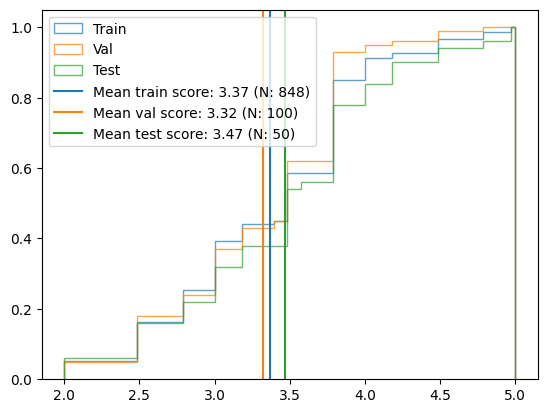

In [97]:
scores_train_clean = np.array([s.score for s in scores_train if s.score != -1])
scores_val_clean = np.array([s.score for s in scores_val if s.score != -1])
scores_test_clean = np.array([s.score for s in scores_test if s.score != -1])

unique_scores = np.unique(np.concatenate((scores_train_clean, scores_val_clean, scores_test_clean)))
bins = np.linspace(min(unique_scores), max(unique_scores), 100)

kwargs = {
    'bins': bins,
    'cumulative': True,
    'histtype': 'step',
    'density': True,
    'alpha': 0.7,
}


plt.hist(scores_train_clean, label='Train', **kwargs)
plt.hist(scores_val_clean, label='Val', **kwargs)
plt.hist(scores_test_clean, label='Test', **kwargs)


score_mean_train = np.mean(scores_train_clean)
score_mean_val = np.mean(scores_val_clean)
score_mean_test = np.mean(scores_test_clean)

plt.axvline(score_mean_train, color='C0', label=f'Mean train score: {score_mean_train:.2f} (N: {len(scores_train_clean)})')
plt.axvline(score_mean_val, color='C1', label=f'Mean val score: {score_mean_val:.2f} (N: {len(scores_val_clean)})')
plt.axvline(score_mean_test, color='C2', label=f'Mean test score: {score_mean_test:.2f} (N: {len(scores_test_clean)})')



plt.legend()

In [184]:
def print_score(scores, data, index):
    score = scores[index]
    print(score.query)
    if score.contexts:
        print(score.contexts)
    print(score.response)
    print(f"\n\n\nTarget:   {data[index]['output']}")
    print(f'Score:    {score.score}')

# print_score(scores_train, data_train, np.argmin(scores_train_clean))
# print_score(scores_test, data_test, np.argmin(scores_test_clean))
print_score(scores_test, data_test, 40)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Categorize the following numbers into even or odd.

### Input:
2, 3, 4, 7
, 11, 13, 15, 17, 19, 21, 23, 26, 30, 34, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 100, 112, 120, 132, 144, 150, 160, 168, 180, 192, 200, 208, 220, 240, 260, 280, 300, 304, 312, 316, 320, 336, 340, 360, 400, 420, 440, 480, 500, 540, 600, 640, 680, 700, 720, 880, 896, 1000, 1050, 1200, 1400, 1600, 1800, 2000, 2100, 2200, 2220, 2230, 2304, 2400, 2410, 2420, 2430, 2440, 2450, 2460, 2480, 2490, 24100, 2420, 2440, 2450, 2460, 2480, 2490, 24100, 2420, 2440, 2450, 2460, 2480, 2490, 24100, 2420, 2440, 2450, 2460, 2480, 2490, 24100, 2420, 2440, 2450, 2460,



Target:   Even: 2, 4; Odd: 3, 7.
Score:    5.0


In [183]:
np.argwhere(np.array([s.score for s in scores_test]) == 5.0)

array([[40]])

In [148]:
print_score(scores_train, data_train, 121)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Answer the following multiple choice question.

Q. Who wrote the book "To Kill a Mockingbird"?
A. Mark Twain
B. Harper Lee
C. Charles Dickens
D. Ernest Hemingway


### Response:
Mark Twain.



Target:   B. Harper Lee
Score:    5.0


In [159]:
responses_train[121]

'\n\n### Response:\nMark Twain.'

In [149]:
data_train[121]

{'instruction': 'Answer the following multiple choice question.\n\nQ. Who wrote the book "To Kill a Mockingbird"?\nA. Mark Twain\nB. Harper Lee\nC. Charles Dickens\nD. Ernest Hemingway',
 'input': '',
 'output': 'B. Harper Lee'}

Even if the instr

In [155]:
print(data_train[121]['instruction'])
print(scores_train[121].response)
print(data_train[121]['output'])

Answer the following multiple choice question.

Q. Who wrote the book "To Kill a Mockingbird"?
A. Mark Twain
B. Harper Lee
C. Charles Dickens
D. Ernest Hemingway


### Response:
Mark Twain.
B. Harper Lee


In [179]:
print(data_test[27]['instruction'])
print(scores_test[27].response)
print(data_test[27]['output'])
print(scores_test[27].score)


Classify the following statement into either positive or negative: "The new design is really impressive."


### Response:
Negative.
Positive. The new design is really impressive.
5.0


In [180]:
evaluator2 = CorrectnessEvaluator(
    llm=correctness_llm,
#     eval_template=correctness_prompt_template,
#     parser_function=score_only_parser,
)

score = await evaluator2.aevaluate(
    query=data_test[27]['instruction'],
    response=scores_test[27].response,
    reference=data_test[27]['output'],
)

In [181]:
print(score.score)
score.feedback

2.0


'The generated answer is relevant to the user query, as it does classify the statement as having a positive sentiment. However, it contains an error in its classification label ("Negative") which deviates from the correct answer provided by the reference answer (Positive). The score could be higher if the classification was accurate.'

In [174]:
print(score.score)
score.feedback

2.0


'The generated answer is not the correct author of "To Kill a Mockingbird", which was actually written by Harper Lee (option B). Although it\'s a relevant answer, it contains an incorrect option and does not fully address the query.'

In [122]:
for d in data_train:
    if 'five-point' in d['instruction']:
        print(d)

{'instruction': 'Classify this statement according to the five-point scale below', 'input': 'The Prime Minister is incompetent and should resign', 'output': 'Strongly agree.'}


In [124]:
for d in data_raw:
    if 'five-point' in d['instruction']:
        print(d)

{'instruction': 'Classify this statement according to the five-point scale below', 'input': 'The Prime Minister is incompetent and should resign', 'output': 'Strongly agree.'}
{'instruction': 'Construct an SVG featuring a five-pointed star with a triangle inside it.', 'input': '', 'output': '<svg xmlns="http://www.w3.org/2000/svg" width="100px" height="100px">\n  <polygon points="50,5 25,80 75,80 25,50 75,50" style="fill:#000; stroke:#000; stroke-width:2;" />\n  <polygon points="50,25 75,50 25,50" style="fill:#000; stroke:#000; stroke-width:2;" />\n</svg>'}


In [75]:
print(scores_train_clean.dtype)
print(scores_val_clean.dtype)
print(scores_test_clean.dtype)

float64
float64
float64


In [68]:
ax.bar?

Signature:
ax.bar(
    x,
    height,
    width=0.8,
    bottom=None,
    *,
    align='center',
    data=None,
    **kwargs,
)
Docstring:
Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

    Bars are often used for categorical data, i.e. string labels below
    the bars. You can provide a list of strings directly to *x*.
    ``bar(['A', 'B', 'C'], [1, 2, 3])`` is often a shorter and more
    convenient notation compared to
    ``bar(range(3), [1, 2, 3], tick_label=['A', 'B', 'C'])``. They are
    equivalent as long as the names are unique. The explicit *tick_label*
    notation draws the names in t

In [56]:
for s in scores_train:
    print(s.score)
    print(s.feedback)
    print(s.query)
    print(s.response)

3.0
None
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the periodic element for atomic number 17?


### Response:
The periodic element for atomic number 17 is NaCl.
3.0
None
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name three innovations of the industrial revolution.


### Response:
Three innovations of the industrial revolution are the spinning jenny, the telegraph, and the spinning jenny.
4.0
None
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Find the total cost of buying the items on the shopping list.

### Input:
Shopping list:
2 bottles of water ($1 each)
1 pack of chips ($3)
1 pack of gum ($2)

### Response:
The total cost of buying the items on the shopping list is $4.
4.5
None
Below is an instruction that describes a task. Write a resp

In [ ]:
s

In [ ]:
scores_train[0].feedback

In [ ]:


        # 

In [ ]:
import torch
torch.mps.is_available()

In [ ]:
torch.linalg.matrix_rank(torch.tensor([[1,2,3], [2,4,6]]).to(torch.float32))

In [ ]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b 
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)   #1
grad_L_b = grad(loss, b, retain_graph=True) 
    


In [ ]:
loss

In [ ]:
device = torch.device('mps')

xs = torch.tensor(
    [
        [0, 0],
        [1, 0],
        [0, 1],
        [1, 1],
    ],
    dtype=torch.float32
)

ys = torch.tensor(
    [
        [0],
        [1],
        [1],
        [0],
    ],
    dtype=torch.float32
)


class XOR(torch.nn.Module):
    def __init__(self):
        super().__init__()
        n_hidden = 1000
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(2, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)


xor = XOR()
xor.to(device)

print(xor(torch.tensor([1., 0.]).to(device)))

with torch.no_grad():
    print(xor(torch.tensor([1., 0.]).to(device)))


dataset = torch.utils.data.TensorDataset(xs, ys)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True)

optimizer = torch.optim.SGD(xor.parameters(), lr=0.5)

num_epochs = 300

losses = []
steps = []
i = 0

for epoch in range(num_epochs):
    xor.train()
    for batch, (x, y) in enumerate(dataloader):
        x = x.to(device)
        y = y.to(device)

        # print(f'Epoch {epoch+1} batch {batch+1}')
        p = xor(x)

        # print('y', y)
        # print('p', p)
        loss = torch.nn.functional.mse_loss(p, y)

        losses.append(loss.item())
        steps.append(i)
        i+=1
        # loss = torch.nn.functional.binary_cross_entropy(p, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # print(f'Epoch {epoch+1} batch {batch+1} loss {loss:.4f}')


import matplotlib.pylab as plt

fig, ax = plt.subplots()

ax.plot(steps, losses)


xor.forward(xs.to(device))



In [ ]:
a

In [ ]:
device

In [ ]:
import time
import torch

def eval_speed(N, device):
    a = torch.rand(N, N).to(device)
    b = torch.rand(N, N).to(device)

    start = time.time()
    a @ b
    end = time.time()

    return end - start


Ns = [10, 100, 1000, 2000, 3000, 5000, 10_000]

cpu_mm_speeds = [eval_speed(N = N, device='cpu') for N in Ns]
mps_mm_speeds = [eval_speed(N = N, device='mps') for N in Ns]




In [ ]:
torch.cuda.device_count()

In [ ]:
torch.mps.device_count()

In [ ]:
torch.cpu.device_count()

In [ ]:
cpu_mm_speeds

In [ ]:
import matplotlib.pylab as plt

fig, ax = plt.subplots()

ax.plot(Ns, cpu_mm_speeds, label='CPU')
ax.plot(Ns, mps_mm_speeds, label='MPS')

ax.set_xlabel('N')
ax.set_ylabel('Time [S]')

ax.set_xscale('log')

ax.legend()

In [ ]:
a = torch.rand(N, N).to('cpu')
b = torch.rand(N, N).to('cpu')

%timeit a @ b

In [ ]:
losses

In [ ]:
torch.optim.SGD?

In [ ]:
torch.nn.functional.l1_loss?

In [ ]:
print(b.grad)
loss.backward()
print(b.grad)


In [ ]:
grad?